# Antiderivative Operator - Aligned Dataset

This tutorial demonstrates the use of learning neural operators for a data driven use case (non-physics informed). 

### References
[1] [Antiderivative operator from an aligned dataset - DeepXDE](https://deepxde.readthedocs.io/en/latest/demos/operator/antiderivative_aligned.html)

[2] [DeepONet Tutorial in JAX](https://github.com/Ceyron/machine-learning-and-simulation/blob/main/english/neural_operators/simple_deepOnet_in_JAX.ipynb)

### Install (Colab only)

In [1]:
# %pip install "neuromancer[examples] @ git+https://github.com/pnnl/neuromancer.git@master"
# %pip install watermark

### Imports

In [2]:
import os

from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import torch
from torch import nn
import time

os.environ["DDE_BACKEND"] = "pytorch"
import deepxde as dde

# FIXME only for development
import sys

sys.path.insert(0, "../../src")

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [3]:
from neuromancer.callbacks import Callback
from neuromancer.modules.activations import activations

In [4]:
# PyTorch random seed
torch.manual_seed(1234)

# NumPy random seed
np.random.seed(1234)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Problem Setup

original source: [https://deepxde.readthedocs.io/en/latest/demos/operator/antiderivative_aligned.html](https://deepxde.readthedocs.io/en/latest/demos/operator/antiderivative_aligned.html)  

We will learn the antiderivative operator 

$$G : v \mapsto u$$

defined by an ODE

$$\frac{du(x)}{dx} = v(x),\;\;x\in [0,1]$$

**Initial Condition:** 
$$u(0) = (0)$$

We learn *G* from a dataset. Each data point in the dataset is one pair of (v,u), generated as follows:

1. A random function *v* is sampled from a Gaussian random field (GRF) with the resolution m = 100.
2. Solve *u* for *v* numerically. We assume that for each *u*, we have the values of *u(x)* in the same N<sub>u</sub> = 100 locations. Because we have the values of *u(x)* in the same locations, we call this dataset as "aligned data".

* Dataset information
    * The training dataset has size 150.
    * The testing dataset has size 1000. (We split this into a dev/test split of size 500 each)
    * Input of the branch net: the functions *v*. It is a matrix of shape (dataset size, m), e.g., (150, 100) for the training dataset.
    * Input of the trunk net: the locations *x* of *u(x)*. It is a matrix of shape (*N<sub>u</sub>*, dimension)
        * i.e., (100,1) for both training and testing datasets.
    * Output: The values of *u(x)* in different locations for different *v*. It is a matrix of shape (dataset size, *N<sub>u</sub>*).
        * e.g., (150, 100) for the training dataset.



## Dataset Prep

Sample $v$ from a Gaussian random field (GRF) with the resolution $m=100$.

Use the [GRF data generator from dde](https://deepxde.readthedocs.io/en/latest/_modules/deepxde/data/function_spaces.html#GRF) to sample a chosen dataset size. We use `dataset_size` as the full data set, which will be split into `n_train`, `n_test` later.

In [5]:
m = 100  # resolution of sampled functions u and their antiderivatives.
space = dde.data.GRF(N=m, length_scale=1)  # GRF space with resolution m
dataset_size = 150  # total dataset size
features = space.random(size=dataset_size)  # sample dataset_size functions from the GRF
h = 1 / m  # step size for Euler integrator
sensors = np.linspace(0, 1, num=m)[:, None]  # m sensor locations between [0,1]

# evaluate the sampled functions at the sensor locations
y = space.eval_batch(features, sensors)
print("Shape of sampled functions:", y.shape)  # (dataset_size, m)


Shape of sampled functions: (150, 100)


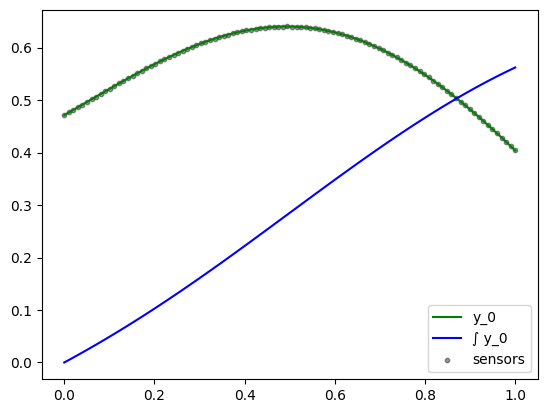

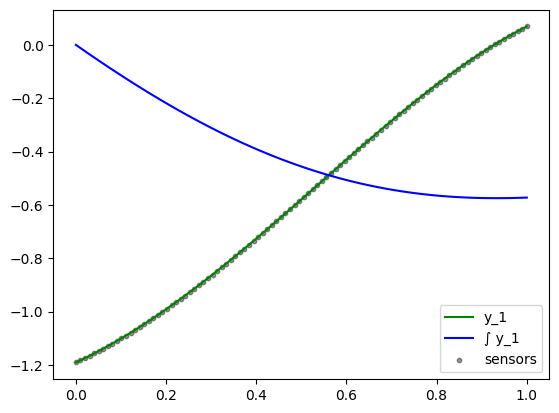

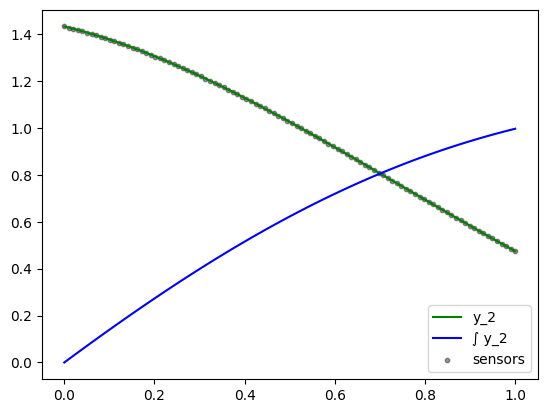

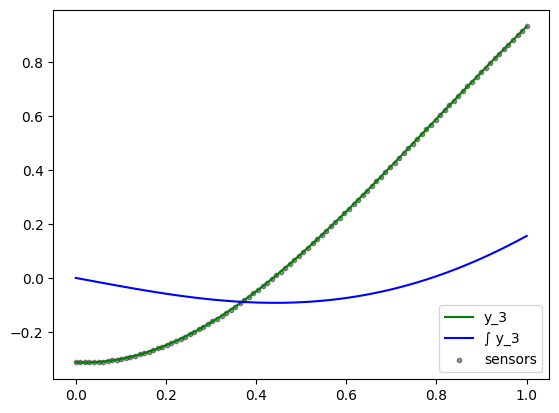

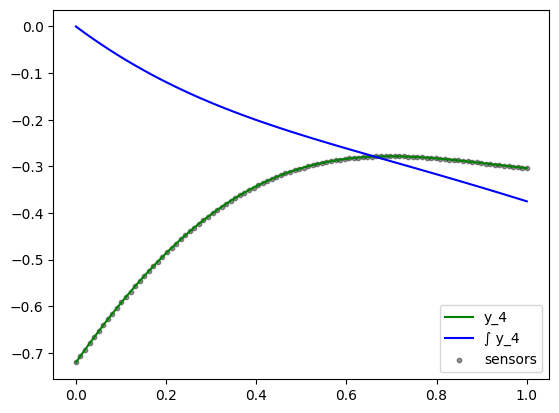

Integrated 150 samples; stored array shape: (150, 100)


In [6]:
anti_y = []  # to store the integrated functions (antiderivatives)
num_plots = 5  # number of functions to plot

# Integrate features using Explicit Euler Method
for idx, yi in enumerate(y):  # y has dataset_size=len(features)
    s = np.zeros(m)
    s0 = 0  # Initial Condition
    for i in range(0, m - 1):
        s[i + 1] = s[i] + h * yi[i]

    # Plotting routine for first num_plots samples
    if idx < num_plots:
        plt.figure()
        plt.plot(sensors, yi, "g", label=f"y_{idx}")
        plt.plot(sensors, s, "b", label=f"∫ y_{idx}")
        plt.scatter(sensors, yi, c="k", s=10, alpha=0.4, label="sensors")
        plt.legend(loc="lower right")

    anti_y.append(s)

anti_y = np.array(anti_y)
plt.show()
print(f"Integrated {len(features)} samples; stored array shape: {anti_y.shape}")


In [7]:
# check dimensions
print("Dimensions check:")
print("features:", features.shape)  # (dataset_size, m)
print("y:", y.shape)  # (dataset_size, m)
print("anti_y:", anti_y.shape)  # (dataset_size, m)
print("sensors:", sensors.shape)  # (m, 1)

Dimensions check:
features: (150, 100)
y: (150, 100)
anti_y: (150, 100)
sensors: (100, 1)


### Function for dataset generation
We create a function for the process above to generate data for train, dev and test

In [8]:
m = 100
space = dde.data.GRF(N=m, length_scale=1)


def generate_GRF_data(dataset_size):
    """Generate dataset of GRF functions and their antiderivatives using Explicit Euler Method

    Args:
        dataset_size (int): Number of samples to generate

    Returns:
        dict: Dictionary with keys "X" and "y" containing input-output pairs
    """
    features = space.random(size=dataset_size)
    sensors = np.linspace(0, 1, num=m)[:, None]
    y = space.eval_batch(features, sensors)

    h = 1 / m
    # Integrate features using Explicit Euler Method
    # Initialise np.zeros((dataset_size, 1), populate rest using y values.
    # S0 = 0 works already as initial condition
    increments = np.concatenate([np.zeros((dataset_size, 1)), y[:, :-1]], axis=1)

    # running sum column‑wise to get antiderivative values
    # s[i + 1] = s[i] + h * yi[i]
    anti_y = np.cumsum(increments, axis=1) * h

    return {"X": [y, sensors], "y": anti_y}

In [9]:
dataset_train = generate_GRF_data(150)
dataset_dev = generate_GRF_data(50)
dataset_test = generate_GRF_data(1000)

# check dimensions
print("Dimensions check:")
print("y:", dataset_train["X"][0].shape)  # (dataset_size, m)
print("anti_y:", dataset_train["y"].shape)  # (dataset_size, m)
print("sensors:", dataset_train["X"][1].shape)  # (m, 1)

Dimensions check:
y: (150, 100)
anti_y: (150, 100)
sensors: (100, 1)


### Create named dictionary datasets

In [10]:
from neuromancer.dataset import DictDataset


def prepare_data(dataset, name):
    """
    Prepares data for DeepONet training in Neuromancer.
    Args:
        dataset (dict): A dictionary containing 'X' and 'y' numpy arrays.
            X[0]: branch inputs (functions) in shape (Nsamples, m)
            X[1]: trunk inputs (sensor locations) (m,1)
            y: outputs (antiderivatives)
        name (str): Name of the dataset.
    Returns:
        data (DictDataset): Neuromancer DictDataset with branch and trunk inputs and outputs.
        Nu (int): Number of outputs
    """
    ## Note: transposing branch input because DictDataset in Neuromancer needs all tensors in the dict to have the same shape at index 0
    branch_inputs = dataset["X"][0].T
    trunk_inputs = dataset["X"][1]
    outputs = dataset["y"].T

    # branch_inputs = dataset["X"][0]
    # trunk_inputs = dataset["X"][1]
    # outputs = dataset["y"]

    Nu = outputs.shape[0]
    Nsamples = outputs.shape[1]
    print(f"{name} dataset: resolution = {Nu}, Nsamples = {Nsamples}")

    # convert to pytorch tensors of float type
    t_branch_inputs = torch.from_numpy(branch_inputs).float()
    t_trunk_inputs = torch.from_numpy(trunk_inputs).float()
    t_outputs = torch.from_numpy(outputs).float()

    data = DictDataset(
        {
            "branch_inputs": t_branch_inputs,
            "trunk_inputs": t_trunk_inputs,
            "outputs": t_outputs,
        },
        name=name,
    )

    return data

In [11]:
train_datadict = prepare_data(dataset_train, name="train")
dev_datadict = prepare_data(dataset_dev, name="dev")
test_datadict = prepare_data(dataset_test, name="test")

# check dimensions
print("Dimensions check:")
print("y:", train_datadict.datadict["branch_inputs"].shape)  # (dataset_size, m)
print("anti_y:", train_datadict.datadict["outputs"].shape)  # (dataset_size, m)
print("sensors:", train_datadict.datadict["trunk_inputs"].shape)  # (m, 1)

train dataset: resolution = 100, Nsamples = 150
dev dataset: resolution = 100, Nsamples = 50
test dataset: resolution = 100, Nsamples = 1000
Dimensions check:
y: torch.Size([100, 150])
anti_y: torch.Size([100, 150])
sensors: torch.Size([100, 1])


### Create torch DataLoaders for the Trainer

In [12]:
batch_size = 100
print(f"batch_size: {batch_size}")
train_loader = torch.utils.data.DataLoader(
    train_datadict,
    batch_size=batch_size,
    collate_fn=train_datadict.collate_fn,
    shuffle=False,
)
dev_loader = torch.utils.data.DataLoader(
    dev_datadict,
    batch_size=batch_size,
    collate_fn=dev_datadict.collate_fn,
    shuffle=False,
)
test_loader = torch.utils.data.DataLoader(
    test_datadict,
    batch_size=batch_size,
    collate_fn=test_datadict.collate_fn,
    shuffle=False,
)

batch_size: 100


## Define DeepONet

The branch net is chosen as a fully connected neural network of size `[m, 40, 40]`, and the the trunk net is a fully connected neural network of size `[dim_x, 40, 40]`, where `dim_x` is diemnsion i.e. 1.

We use `neuromancer.modules.blocks.MLP` to create the MLPs in Neuromancer abstraction

In [13]:
from neuromancer.modules.blocks import MLP

in_size_branch = m  # input size for branch net
width_size = 40  # width of hidden layers
depth_branch = 2  # depth of branch net
interact_size = 40  # size of the interaction layer

branch_net = MLP(
    insize=in_size_branch,
    outsize=interact_size,
    nonlin=nn.ReLU,
    hsizes=[width_size] * depth_branch,
    bias=True,
)

dim_x = 1  # dimension of the input x to the trunk net
depth_trunk = 2  # depth of trunk net

trunk_net = MLP(
    insize=dim_x,
    outsize=interact_size,
    nonlin=nn.ReLU,
    hsizes=[width_size] * depth_trunk,
    bias=True,
)


In [15]:
from neuromancer.dynamics.operators import DeepONetCartesianProd

deeponet = DeepONetCartesianProd(
    branch_net=branch_net, trunk_net=trunk_net, bias=True, return_transposed=True
)

In [16]:
from neuromancer.system import Node

node_deeponet = Node(
    deeponet, ["branch_inputs", "trunk_inputs"], ["g"], name="deeponet"
)
print(node_deeponet)

deeponet(branch_inputs, trunk_inputs) -> g


## Objective and Constraints in NeuroMANCER

We use Mean Squared Error(MSE) for our loss function

$$\sum_{i=1}^{D}(x_i-y_i)^2$$



In [17]:
from neuromancer.problem import Problem
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss

var_y_est = variable("g")
var_y_true = variable("outputs")

nodes = [node_deeponet]
var_loss = (var_y_est == var_y_true) ^ 2
var_loss.name = "residual_loss"
objectives = [var_loss]

loss = PenaltyLoss(objectives, constraints=[])

problem = Problem(nodes, loss=loss, grad_inference=True)

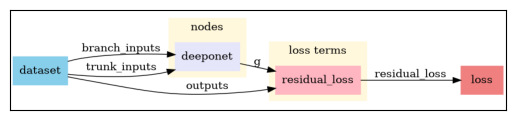

In [18]:
problem.show()

## Problem Solution in NeuroMANCER

In [19]:
lr = 0.001  # step size for gradient descent
epochs = 10000  # number of training epochs
epoch_verbose = 100  # print loss/display loss plot when this many epochs have occurred
warmup = 100  # number of epochs to wait before enacting early stopping policy
patience = 0  # number of epochs with no improvement in eval metric to allow before early stopping

optimizer = torch.optim.AdamW(problem.parameters(), lr=lr)

### Construct Trainer and solve the problem

In [20]:
from neuromancer.trainer import Trainer


class LossHistoryCallback(Callback):
    def end_epoch(self, trainer, output):
        if trainer.current_epoch % trainer.epoch_verbose == 0:
            train_loss_history = [
                l.detach().cpu().numpy() for l in trainer.loss_history["train"]
            ]
            dev_loss_history = [
                l.detach().cpu().numpy() for l in trainer.loss_history["dev"]
            ]
            clear_output(wait=True)
            plt.semilogy(train_loss_history, label="Train loss")
            plt.semilogy(dev_loss_history, label="Dev loss")
            plt.xlabel("# Epochs")
            plt.legend()
            plt.show()


loss_history_callback = LossHistoryCallback()


# define trainer
trainer = Trainer(
    problem.to(device),
    train_data=train_loader,
    dev_data=dev_loader,
    test_data=test_loader,
    optimizer=optimizer,
    logger=None,
    callback=loss_history_callback,
    epochs=epochs,
    patience=patience,
    epoch_verbose=epoch_verbose,
    train_metric="train_loss",
    dev_metric="dev_loss",
    test_metric="test_loss",
    eval_metric="dev_loss",
    warmup=warmup,
    device=device,
)

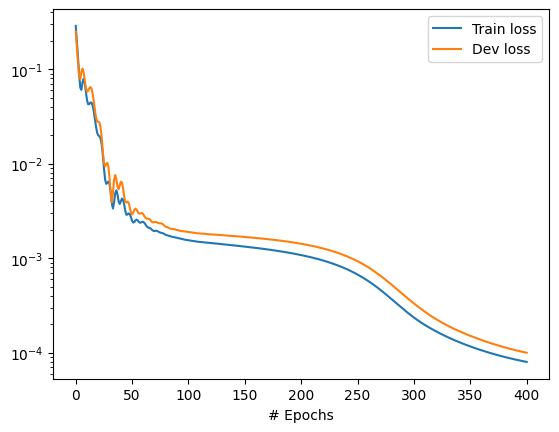

Early stopping!!!
CPU times: user 4.18 s, sys: 563 ms, total: 4.74 s
Wall time: 5.24 s


In [21]:
%%time
best_model = trainer.train()

In [22]:
# load best trained model
best_outputs = trainer.test(best_model)
problem.load_state_dict(best_model)

<All keys matched successfully>

In [23]:
train_loss_history = [l.detach().cpu().numpy() for l in trainer.loss_history["train"]]
dev_loss_history = [l.detach().cpu().numpy() for l in trainer.loss_history["dev"]]
mean_test_loss = best_outputs["mean_test_loss"].detach().cpu().numpy()
print(mean_test_loss)
print(f"len(train_loss_history): {len(train_loss_history)}")
print(f"len(dev_loss_history): {len(dev_loss_history)}")

0.00010553469
len(train_loss_history): 410
len(dev_loss_history): 410


## Plot loss history w/ mean test loss

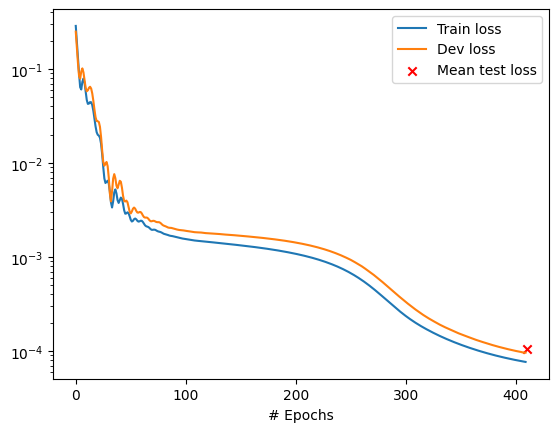

In [24]:
plt.semilogy(train_loss_history, label="Train loss")
plt.semilogy(dev_loss_history, label="Dev loss")
plt.scatter(
    len(train_loss_history), mean_test_loss, label="Mean test loss", c="red", marker="x"
)
plt.xlabel("# Epochs")
plt.legend()
plt.show()

## Compare results

torch.Size([100, 1]) torch.Size([100, 1])


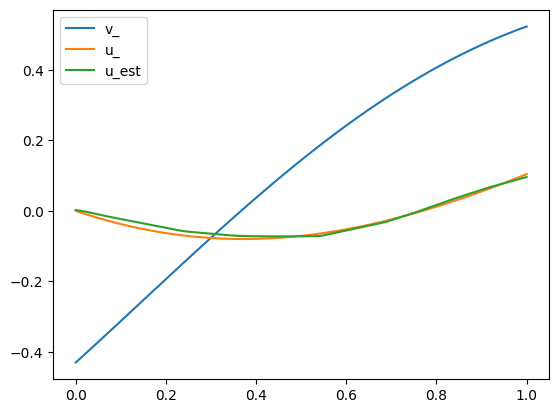

In [25]:
k = 211  # k is the k-th function among the 500 test functions
v_ = test_datadict.datadict["branch_inputs"][:, k].reshape(-1, 1)
x_ = test_datadict.datadict["trunk_inputs"]
print(v_.shape, x_.shape)

v_ = v_.to(device)
x_ = x_.to(device)
# KeyError 'outputs' in Variable in loss
# with torch.no_grad():
#    res = problem.forward({'branch_inputs':v_, 'trunk_inputs':x_})
res = problem.predict({"branch_inputs": v_, "trunk_inputs": x_})

u_ = test_datadict.datadict["outputs"][:, k]
u_est = res["g"]

plt.plot(x_.detach().cpu().numpy(), v_.detach().cpu().numpy(), label="v_")
plt.plot(x_.detach().cpu().numpy(), u_.detach().cpu().numpy(), label="u_")
plt.plot(x_.detach().cpu().numpy(), u_est.detach().cpu().numpy(), label="u_est")

plt.legend()


## Symbolic Integral Examples

torch.Size([100, 1]) torch.Size([100, 1])


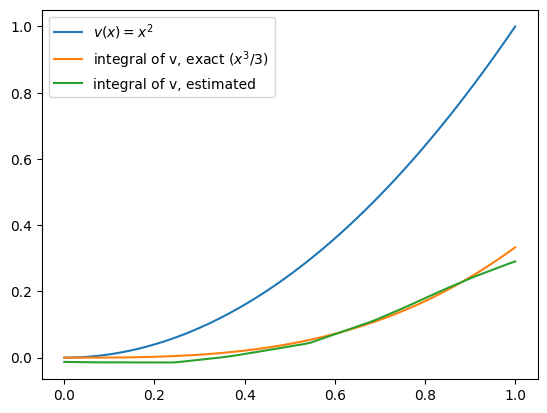

In [26]:
x_ = train_datadict.datadict["trunk_inputs"]
v_ = torch.pow(x_, 2).reshape(-1, 1)

print(v_.shape, x_.shape)

v_ = v_.to(device)
x_ = x_.to(device)

# KeyError 'outputs' in Variable in loss
# with torch.no_grad():
# with torch.no_grad():
#    res = problem.forward({'branch_inputs':v_, 'trunk_inputs':x_})
res = problem.predict({"branch_inputs": v_, "trunk_inputs": x_})

u_ = (1.0 / 3.0) * torch.pow(x_, 3).reshape(-1, 1)
u_est = res["g"]

plt.plot(x_.detach().cpu().numpy(), v_.detach().cpu().numpy(), label="$v(x) = x^2$")
plt.plot(
    x_.detach().cpu().numpy(),
    u_.detach().cpu().numpy(),
    label="integral of v, exact ($x^3/3$)",
)
plt.plot(
    x_.detach().cpu().numpy(),
    u_est.detach().cpu().numpy(),
    label="integral of v, estimated",
)
plt.legend()


torch.Size([100, 1]) torch.Size([100, 1])


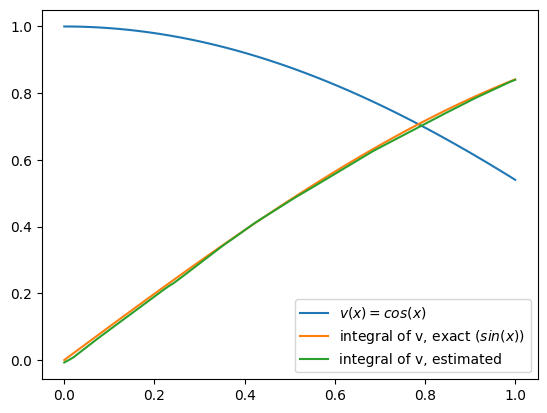

In [27]:
x_ = train_datadict.datadict["trunk_inputs"]
v_ = torch.cos(x_).reshape(-1, 1)

print(v_.shape, x_.shape)

v_ = v_.to(device)
x_ = x_.to(device)

res = problem.predict({"branch_inputs": v_, "trunk_inputs": x_})

u_ = torch.sin(x_).reshape(-1, 1)
u_est = res["g"]

plt.plot(x_.detach().cpu().numpy(), v_.detach().cpu().numpy(), label="$v(x) = cos(x)$")
plt.plot(
    x_.detach().cpu().numpy(),
    u_.detach().cpu().numpy(),
    label="integral of v, exact ($sin(x)$)",
)
plt.plot(
    x_.detach().cpu().numpy(),
    u_est.detach().cpu().numpy(),
    label="integral of v, estimated",
)
plt.legend()

### Watermark

In [28]:
# %load_ext watermark
# %watermark
# %watermark --iversions